<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/#create=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [ ]:
nombre = input("📝 Ingresa tu nombre completo:")
correo = input("📧 Ingresa tu correo electrónico:")
cedula = input("🔢 Ingresa los últimos 4 dígitos de tu cédula: ")

## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

<p align="center">
    <img src="imgs\sp_2_e1.png" alt="sp_2_e1" width="900"  height="400">
</p>


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr, spearmanr, chi2_contingency

Medidas de tendencia central:
Media:   6.43 
Mediana: 6.70 
Moda:    4.90 


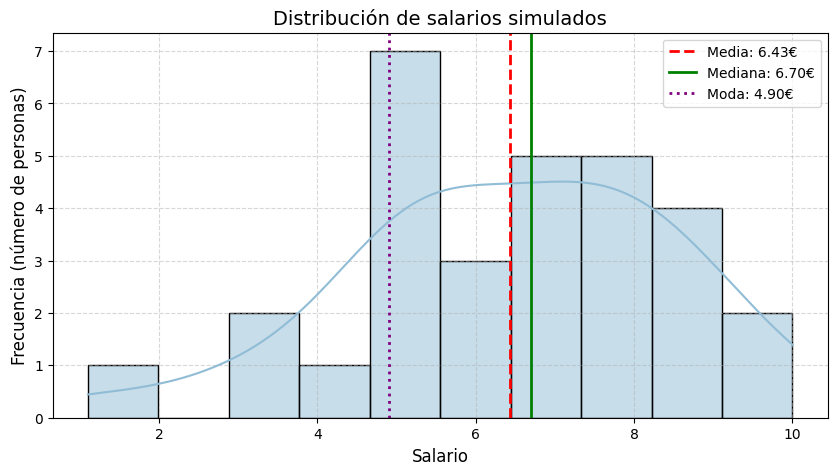

In [8]:

#params
base=25134 # mi cedula francesa
np.random.seed(base)
media_teorica = (base%10)+2
desviacion_estandar = 2
tamanio_muestra = 30

#generación de una tabla salarial aleatoria y limpieza (sin valores negativos)
salarios = np.random.normal(loc=media_teorica, scale=desviacion_estandar, size=tamanio_muestra).round(1)
np.clip(salarios, a_min=0, a_max=None, out=salarios) #borrar los salarios < 0

#cálculo de medias, mediana, moda y visualización
media = np.mean(salarios)
modana = np.median(salarios)
moda = stats.mode(salarios, keepdims=True)
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f} ")
print(f"Mediana: {modana:.2f} ")
print(f"Moda:    {moda.mode[0]:.2f} ")

# plot
plt.figure(figsize=(10, 5))
# Visualización con seaborn: frecuencia en función del salario
sns.histplot(salarios, bins=10, kde=True, color="#91BCD6")

# lineas y leyenda
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}€')
plt.axvline(modana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {modana:.2f}€')
plt.axvline(moda.mode[0], color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda.mode[0]:.2f}€')
plt.title("Distribución de salarios simulados", fontsize=14)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia (número de personas)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

## Interpretacion

La distribución de los salarios simulados presenta una media de 6,43 €, una mediana de 6,70 € y una moda de 4,90 €. Se observa que la media es ligeramente inferior a la mediana, lo que refleja la influencia de algunos salarios bajos que reducen el promedio. Aunque el valor más frecuente es 4,90 €, la mayoría de los salarios se concentran entre 5 € y 8 €, mostrando una distribución ligeramente asimétrica hacia la izquierda.

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

<p align="center">
    <img src="imgs\sp_2_e2.png" alt="sp_2_e2" width="900"  height="400">
</p>

Medidas de dispersión:
Rango:              8.90
Varianza:           3.93
Desviación estándar:1.98
Coef. de variación: 0.31


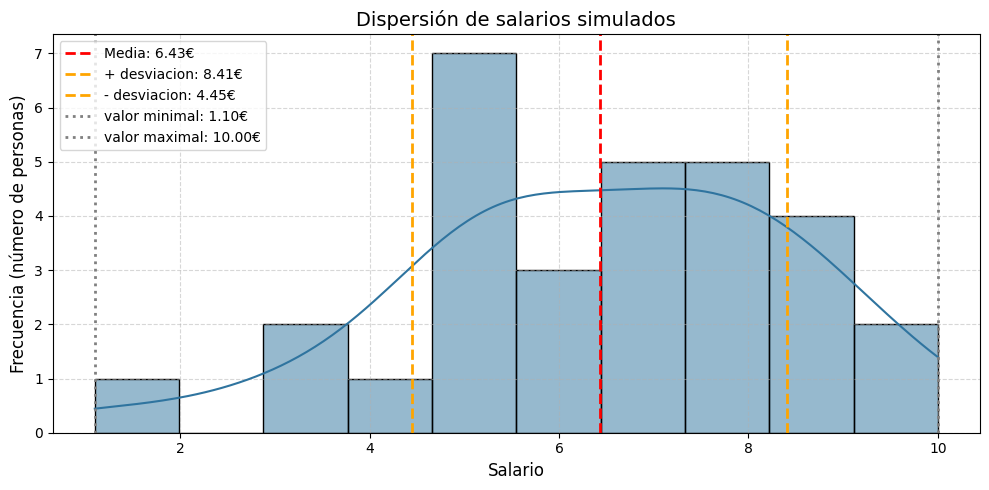

In [9]:
rango = np.max(salarios) - np.min(salarios)  # diferencia entre el valor máximo y mínimo
varianza = np.var(salarios)
desviacion_estandar = np.std(salarios)
coef_var = desviacion_estandar / media

print("Medidas de dispersión:")
print(f"Rango:              {rango:.2f}")
print(f"Varianza:           {varianza:.2f}")
print(f"Desviación estándar:{desviacion_estandar:.2f}")
print(f"Coef. de variación: {coef_var:.2f}")

# Visualización de la dispersión
plt.figure(figsize=(10, 5))
sns.histplot(salarios, bins=10, kde=True, color="#2F749F")


plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}€')
plt.axvline(media + desviacion_estandar, color='orange', linestyle='--', linewidth=2, label=f'+ desviacion: {(media+desviacion_estandar):.2f}€')
plt.axvline(media - desviacion_estandar, color='orange', linestyle='--', linewidth=2, label=f'- desviacion: {(media-desviacion_estandar):.2f}€')
plt.axvline(np.min(salarios), color='grey', linestyle=':', linewidth=2, label=f'valor minimal: {(np.min(salarios)):.2f}€')
plt.axvline(np.max(salarios), color='grey', linestyle=':', linewidth=2, label=f'valor maximal: {(np.max(salarios)):.2f}€')

plt.title("Dispersión de salarios simulados", fontsize=14)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia (número de personas)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()



## Interpretacion

La media de los salarios es de 6,43 €, mientras que el rango alcanza 8,90 €, lo que indica una gran diferencia entre el salario más bajo (1,10 €) y el más alto (10,00 €). La varianza es de 3,93 y la desviación estándar de 1,98 €, lo que significa que, en promedio, los salarios se alejan de la media en unos 2 €. Además, el coeficiente de variación (0,31) muestra una dispersión moderada en relación con la media.

En el histograma se observa que la mayoría de los salarios se concentran alrededor de la media, entre 4,45 € y 8,41 € (es decir, una desviación estándar por debajo y por encima de la media). Sin embargo, los valores extremos explican el rango amplio y justifican la variabilidad de la distribución.

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

<p align="center">
    <img src="imgs\sp_2_e3.png" alt="sp_2_e3" width="900"  height="400">
</p>



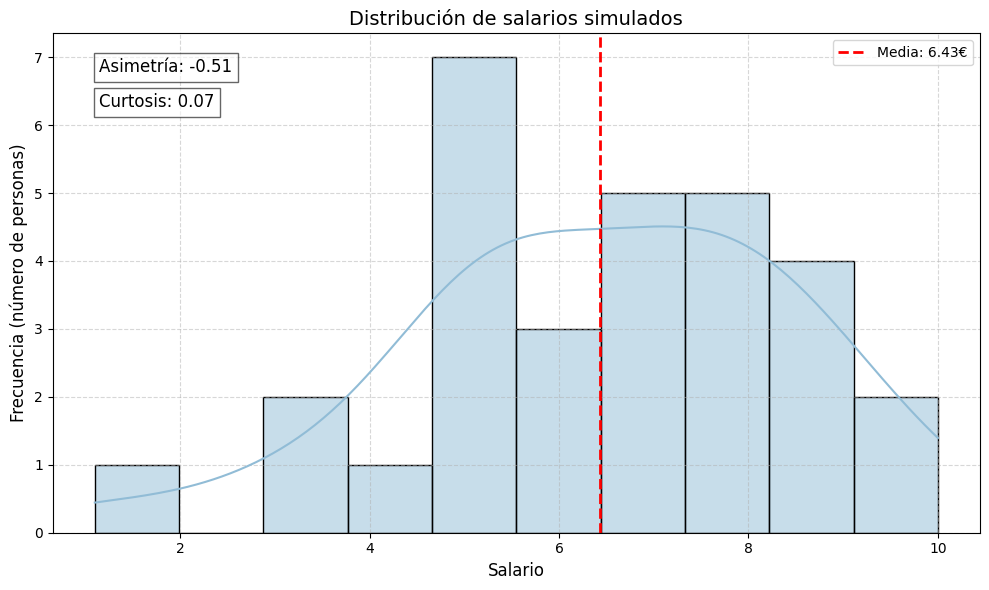

In [10]:

# asimetria y curtosis
asimetria = stats.skew(salarios)     
curtosis_valor = stats.kurtosis(salarios)


plt.figure(figsize=(10, 6))
sns.histplot(salarios, kde=True, color="#91BCD6", bins=10)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}€')

# text box
plt.text(0.05, 0.95, f"Asimetría: {asimetria:.2f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))
plt.text(0.05, 0.88, f"Curtosis: {curtosis_valor:.2f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

plt.title("Distribución de salarios simulados", fontsize=14)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia (número de personas)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Interpretación

El valor de asimetría es -0.51, lo que indica que la distribución de los salarios está ligeramente sesgada hacia la izquierda (asimetría negativa). Esto significa que hay una mayor concentración de salarios altos y algunos valores bajos extremos.

El valor de curtosis es 0.07, muy cercano a 0, lo que indica que la distribución tiene una curtosis similar a la normal (mesocúrtica). Es decir, no hay una presencia significativa de valores extremos ni colas especialmente pronunciadas.

En resumen, la distribución de los salarios simulados es aproximadamente simétrica, con una ligera asimetría hacia la izquierda y una concentración de datos similar a la de una distribución

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

<p align="center">
    <img src="imgs\sp_2_e4.png" alt="sp_2_e4" width="900"  height="400">
</p>


Deciles D1-D9:
D1: 4.46 €
D2: 4.90 €
D3: 5.44 €
D4: 5.72 €
D5: 6.70 €
D6: 7.14 €
D7: 7.62 €
D8: 8.08 €
D9: 8.65 €


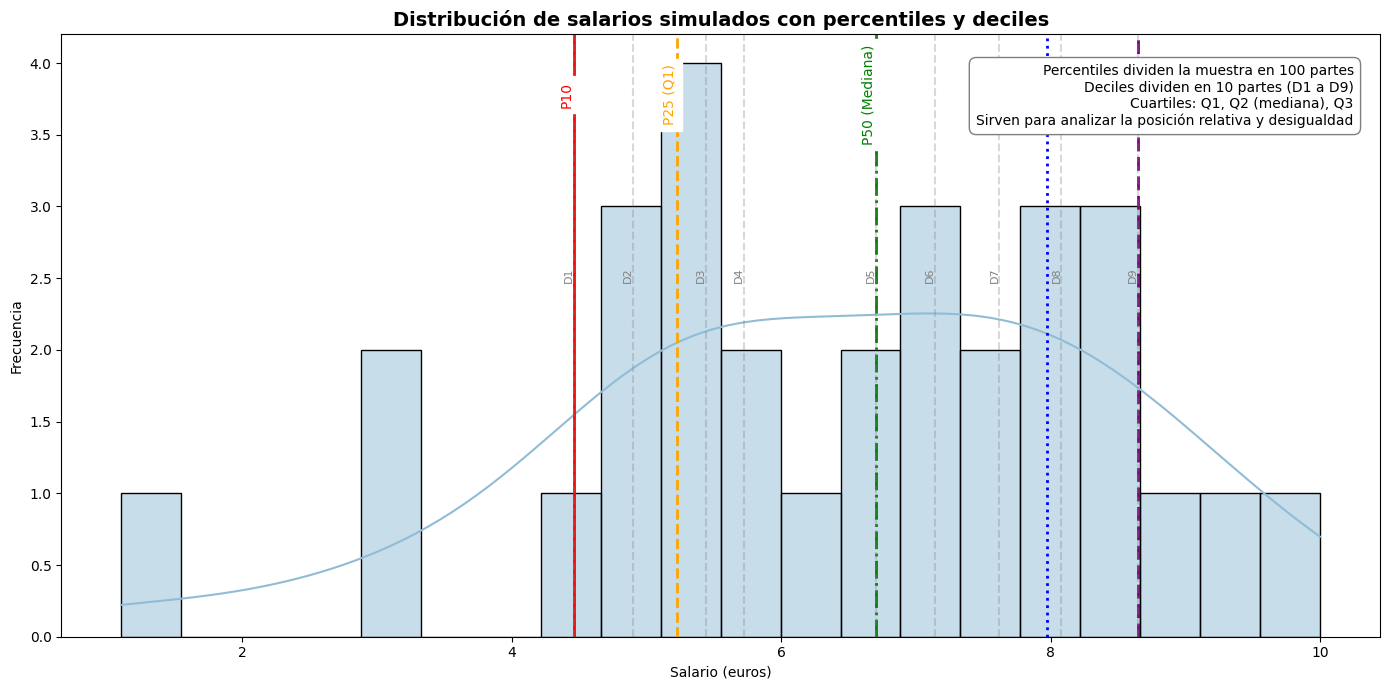

In [11]:
# Cálculo de percentiles y deciles
percentiles = {
    'P10': {'valor': np.percentile(salarios, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(salarios, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(salarios, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(salarios, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(salarios, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}
deciles = {f'D{i}': np.percentile(salarios, i * 10) for i in range(1, 10)}

print("Deciles D1-D9:")
for etiqueta, valor in deciles.items():
    print(f"{etiqueta}: {valor:.2f} €")

# Visualización de la distribución y percentiles
plt.figure(figsize=(14, 7))
sns.histplot(salarios, kde=True, color='#91BCD6', bins=20)

# percentiles destacados
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.9, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             backgroundcolor='white')

# lineas deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.6, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')


texto = (
    "Percentiles dividen la muestra en 100 partes\n"
    "Deciles dividen en 10 partes (D1 a D9)\n"
    "Cuartiles: Q1, Q2 (mediana), Q3\n"
    "Sirven para analizar la posición relativa y desigualdad"
)
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

# Títulos y estilo
plt.title("Distribución de salarios simulados con percentiles y deciles", fontsize=14, fontweight='bold')
plt.xlabel("Salario (euros)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Interpretación

Los deciles muestran cómo se distribuyen los salarios en la muestra. Por ejemplo, el D1 es 4,46 €, lo que significa que el 10% de las personas gana menos de esa cantidad. El D5 es 6,70 €, así que la mitad de la muestra gana menos de ese valor. El D9 es 8,65 €, indicando que solo el 10% supera ese salario.

En el gráfico, se observa que la mayoría de los salarios se concentran entre D3 (5,44 €) y D8 (8,08 €), lo que indica que la mayor parte de la población tiene salarios en ese rango. Hay poca dispersión y pocos valores extremos, lo que refleja una distribución relativamente homogénea de los salarios en

## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**. 
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

<p align="center">
    <img src="imgs\sp_2_e5.png" alt="sp_2_e5" width="900"  height="400">
</p>

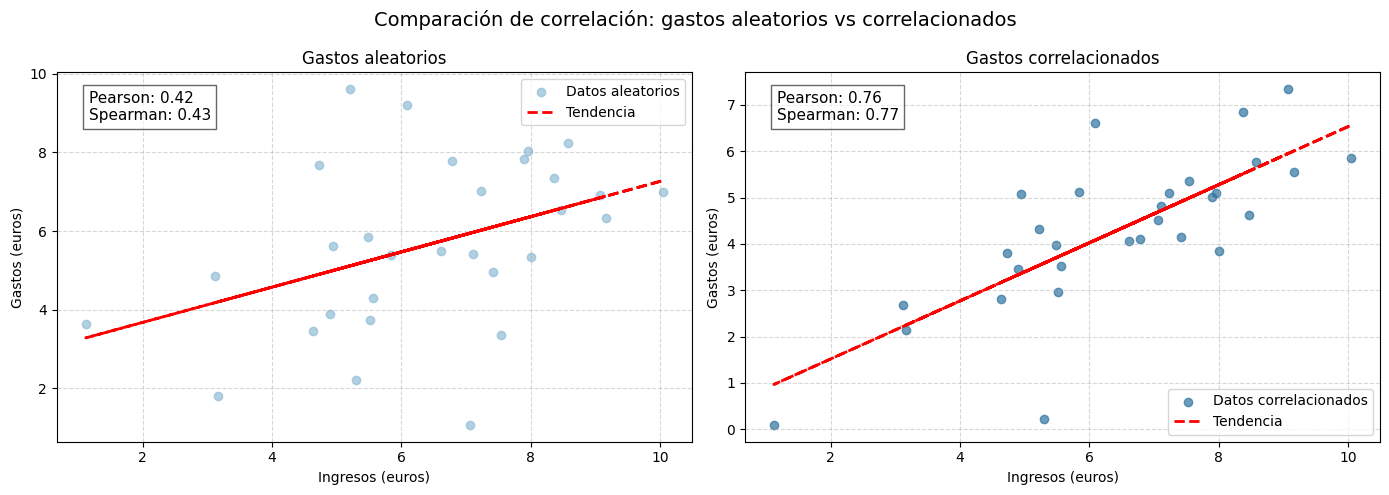

In [12]:
# Voy a comparar dos escenarios: gastos aleatorios vs gastos correlacionados

np.random.seed(base)

# variables simuladas
ingresos = np.random.normal(loc=media_teorica, scale=2, size=30)
gastos_random = np.random.normal(loc=media_teorica, scale=2, size=30)  # sin relación
gastos_correlacionados = ingresos * 0.7 + np.random.normal(0, 1, 30)   # con relación

# correlaciones
r_pearson_rand, _ = pearsonr(ingresos, gastos_random)
r_spearman_rand, _ = spearmanr(ingresos, gastos_random)
r_pearson_corr, _ = pearsonr(ingresos, gastos_correlacionados)
r_spearman_corr, _ = spearmanr(ingresos, gastos_correlacionados)

# gráfico de dispersión
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# gastos aleatorios
axs[0].scatter(ingresos, gastos_random, color="#91BCD6", alpha=0.7, label="Datos aleatorios")
m1, b1 = np.polyfit(ingresos, gastos_random, 1)
axs[0].plot(ingresos, m1*ingresos + b1, color="red", linestyle="--", linewidth=2, label="Tendencia")
axs[0].text(0.05, 0.95, f"Pearson: {r_pearson_rand:.2f}\nSpearman: {r_spearman_rand:.2f}",
            transform=axs[0].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.6))
axs[0].set_title("Gastos aleatorios")
axs[0].set_xlabel("Ingresos (euros)")
axs[0].set_ylabel("Gastos (euros)")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# gastos correlacionados
axs[1].scatter(ingresos, gastos_correlacionados, color="#2F749F", alpha=0.7, label="Datos correlacionados")
m2, b2 = np.polyfit(ingresos, gastos_correlacionados, 1)
axs[1].plot(ingresos, m2*ingresos + b2, color="red", linestyle="--", linewidth=2, label="Tendencia")
axs[1].text(0.05, 0.95, f"Pearson: {r_pearson_corr:.2f}\nSpearman: {r_spearman_corr:.2f}",
            transform=axs[1].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.6))
axs[1].set_title("Gastos correlacionados")
axs[1].set_xlabel("Ingresos (euros)")
axs[1].set_ylabel("Gastos (euros)")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Comparación de correlación: gastos aleatorios vs correlacionados", fontsize=14)
plt.tight_layout()
plt.show()

## Interpretación

En el primer gráfico (gastos aleatorios), los coeficientes de correlación son bajos: Pearson = 0.42 y Spearman = 0.43. Esto indica que no existe una relación clara entre ingresos y gastos, el gráfico muestra simplemente una nube de puntos dispersos. Aunque la función `polyfit` dibuja una línea de tendencia, esta no representa una relación real, solo ajusta una recta a los datos por defecto.

En el segundo gráfico (gastos correlacionados), los coeficientes son altos: Pearson = 0.76 y Spearman = 0.77. Aquí sí se observa una tendencia clara: a mayor ingreso, mayor gasto. Los puntos siguen la línea de regresión y la relación es evidente. Esto es normal, porque hicimos a propósito que las variables estén correlacionadas con la fórmula usada para gastos correlacionados.

En resumen, la correlación alta refleja una dependencia entre las variables, mientras que la baja correlación muestra independencia. Es importante no interpretar la línea de tendencia como una relación real cuando los datos son aleatorios. Además, la correlación de Spearman y Pearson son similares porque la relación es aproximadamente lineal en el caso. Cabe destacar que los coeficientes de Pearson y Spearman pueden diferir según el tipo de relación entre las variables. Por ejemplo, si la relación no es lineal pero sí monótona (creciente o decreciente), el coeficiente de Pearson puede ser bajo mientras que el de Spearman puede ser alto. Por eso es importante analizar ambos para entender mejor la naturaleza de la correlación.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

<p align="center">
    <img src="imgs\sp_2_e6.png" alt="sp_2_e6" width="900"  height="700">
</p>

Chi2 = 0.705, p-valor = 0.703
Grados de libertad: 2
Frecuencias esperadas:
 col_0      No    Sí
row_0              
Básico    5.4  12.6
Medio     6.6  15.4
Superior  6.0  14.0 



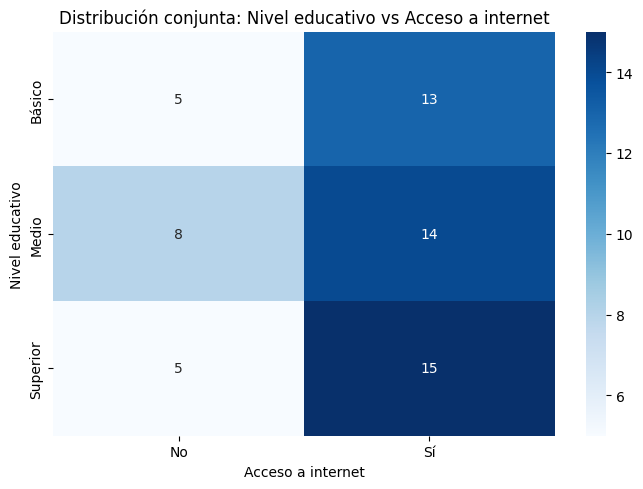

In [13]:
np.random.seed(base)

# Simulamos 60 personas
n = 60
niveles = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

# Nivel educativo y acceso a internet 
nivel_educativo = np.random.choice(niveles, size=n, p=[0.3, 0.4, 0.3])
acceso_internet = np.random.choice(internet, size=n, p=[0.7, 0.3])
tabla = pd.crosstab(nivel_educativo, acceso_internet)

# chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"Chi2 = {chi2:.3f}, p-valor = {p:.3f}")
print("Grados de libertad:", dof)
print("Frecuencias esperadas:\n", pd.DataFrame(expected, index=tabla.index, columns=tabla.columns), "\n")

plt.figure(figsize=(7, 5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.xlabel("Acceso a internet")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

## Interpretación:
La tabla de contingencia muestra la relación entre nivel educativo y acceso a internet. El estadístico Chi-cuadrado obtenido es 0.705 y el p-valor es 0.703. Estos valores indican que no existe asociación estadística significativa entre ambas variables en la muestra analizada. Si el p-valor fuera menor a 0.05, habría evidencia de asociación; pero en este caso, como el p-valor es